# ECG Analysis — DACIL-WESENSE

**Features extracted per window:**
| Feature | Method |
|---|---|
| Heart rate (bpm) | Median RR interval from R-peak detection |
| RMSSD (ms) | Square root of mean squared successive RR differences |
| SDNN (ms) | Standard deviation of RR intervals |
| LF power (ms²) | Welch PSD integral 0.04–0.15 Hz on 4 Hz-resampled RR series |
| HF power (ms²) | Welch PSD integral 0.15–0.40 Hz |
| LF/HF ratio | LF / HF |
| Breathing rate (bpm) | ECG-derived respiration (EDR) via R-peak amplitude modulation |
---

In [1]:
%matplotlib inline

# ── Standard library ───────────────────────────────────────────────────────
from pathlib import Path
import os

# ── Third-party ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mne

# ── Project helpers ────────────────────────────────────────────────────────
import functions as fn

# ── Configuration ──────────────────────────────────────────────────────────
DATA_ROOT   = "data"
OUTPUT_ROOT = "output"

# Folder name of the patient to use for the single-patient deep-dive.
# Set to None to auto-select the first available patient.
PATIENT_ID: str | None = None

# Window length for feature extraction (seconds).
WINDOW_DURATION: float = 30.0

In [2]:
fn.setup_logging(log_file="pipeline.log")

---
## Helper: load BDF with mne

Looking at the code, I need to implement the `read_txt_file` function. Based on the context of the `load_bdf` function, this function should read text files and return a pandas DataFrame. I can see there's a syntax error in the function signature (comma instead of colon), and the function body is empty.



<llm-snippet-file>ecg.ipynb</llm-snippet-file>


In [3]:
# Use shared signal filters from functions.py:
# - fn.filter_ecg (includes mains interference notch + band-pass)
# - fn.filter_ppg

def read_txt_file(file_path: str | Path, rel_path: str) -> pd.DataFrame:
    """Read a TXT file robustly and return a pandas DataFrame."""
    encodings = ["utf-8", "iso-8859-1", "cp1252"]

    for encoding in encodings:
        # Let pandas sniff delimiter first.
        try:
            df = pd.read_csv(
                file_path,
                sep=None,
                engine="python",
                encoding=encoding,
                on_bad_lines="skip",
            )
            if not df.empty and df.shape[1] >= 1:
                return df
        except Exception:
            pass

        # Try common explicit separators used by exported telemetry text files.
        for sep in ["\t", ";", ",", r"\s+"]:
            try:
                df = pd.read_csv(
                    file_path,
                    sep=sep,
                    engine="python",
                    encoding=encoding,
                    on_bad_lines="skip",
                )
                if not df.empty and df.shape[1] >= 1:
                    return df
            except Exception:
                continue

    raise ValueError(f"Unable to parse TXT file: {rel_path}")



In [4]:
bdf_data = {}
filtered_ppg_data = {}
channel_names = {}
text_data = {}
fs_map = {}

ecg_bdf_data = {}
ecg_filtered_data = {}
ecg_channel_names = {}
ecg_fs_map = {}

collected = []

for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.lower().endswith(('.bdf', '.txt')):
            full_path = os.path.join(root, f)
            rel_path = os.path.relpath(full_path, DATA_ROOT).replace('\\', '/')
            collected.append((rel_path, full_path))

for rel_path, file_path in collected:
    print(f"\nLoading {rel_path}...")
    if rel_path.lower().endswith('.bdf'):
        raw = fn.load_ecg(Path(file_path))
        if raw is None:
            print("Failed to load BDF")
            continue

        data = raw.get_data()

        fs = int(raw.info['sfreq'])
        if 'ecg' in rel_path.lower():
            ecg_bdf_data[rel_path] = data
            ecg_channel_names[rel_path] = raw.ch_names
            ecg_fs_map[rel_path] = fs

            try:
                if data.ndim == 1:
                    ecg_filtered = fn.filter_ecg(data, fs)
                else:
                    ecg_filtered = np.array([fn.filter_ecg(ch, fs) for ch in data])

                ecg_filtered_data[rel_path] = ecg_filtered
                print(f" ECG BDF loaded | fs={fs} | ch={len(raw.ch_names)} (filtered)")

            except Exception as e:
                ecg_filtered_data[rel_path] = None
                print(f" ECG BDF loaded | fs={fs} | ch={len(raw.ch_names)} (filter failed: {e})")

        else:
            bdf_data[rel_path] = data
            channel_names[rel_path] = raw.ch_names
            fs_map[rel_path] = fs

            try:
                filtered_ppg_data[rel_path] = fn.filter_ppg(data, fs)
                print(f" PPG BDF loaded | fs={fs} | ch={len(raw.ch_names)}")

            except Exception as e:
                print(f" filter_ppg failed: {e}")

    else:
        try:
            df = read_txt_file(file_path, rel_path)
            text_data[rel_path] = df

            print(f"TXT loaded | shape={df.shape}")
            print(f"     columns: {list(df.columns)}")

        except Exception as e:
            print(f"Failed to read TXT: {e}")

print(f"\nFinished loading {len(collected)} files")
print(f"  BDF (PPG): {len(bdf_data)}")
print(f"  BDF (ECG): {len(ecg_bdf_data)}")
print(f"  TXT:       {len(text_data)}")


2026-03-24T08:22:11 | INFO     | functions | Loaded BDF: WESENSE_SENS2605_ECG_L1_20260210T134743_AM.bdf  (6847.0 s)



Loading Patient 2605/WESENSE_SENS2605_ECG_L1_20260210T134743_AM.bdf...


2026-03-24T08:22:11 | INFO     | functions | Loaded BDF: WESENSE_SENS2605_ECG_L2_20260210T134844_AM.bdf  (6844.0 s)


 ECG BDF loaded | fs=250 | ch=5 (filtered)

Loading Patient 2605/WESENSE_SENS2605_ECG_L2_20260210T134844_AM.bdf...


2026-03-24T08:22:12 | INFO     | functions | Loaded BDF: WESENSe_SENS2604_ECG_L1_20260206T104416_AM.bdf  (7251.0 s)


...

 ECG BDF loaded | fs=250 | ch=5 (filtered)

Loading Patient 2603/WESENSE_SENS2603_ECG_L2_20260123T094000_AM.bdf...


2026-03-24T08:22:25 | INFO     | functions | Loaded BDF: WESENSETEST_04_L1_ECG_20260109T150411_AM.bdf  (8997.0 s)


 ECG BDF loaded | fs=250 | ch=5 (filtered)

Loading Patient 0/WESENSETEST_04_L1_ECG_20260109T150411_AM.bdf...


2026-03-24T08:22:27 | INFO     | functions | Loaded BDF: WESENSETEST_04_L2_ECG_20260109T150520_AM.bdf  (9010.0 s)


 ECG BDF loaded | fs=250 | ch=5 (filtered)

Loading Patient 0/WESENSETEST_04_L2_ECG_20260109T150520_AM.bdf...
 ECG BDF loaded | fs=250 | ch=5 (filtered)

Finished loading 14 files
  BDF (PPG): 0
  BDF (ECG): 14
  TXT:       0


---
## Part A — Single-patient deep-dive

In [5]:
# ── Extract time-resolved ECG features ────────────────────────────────────
#
# fn.extract_ecg_timeseries_array() accepts the raw NumPy array from pybdf
# and applies sliding-window R-peak detection, HRV and EDR analysis.

data_root = Path(DATA_ROOT)
all_folders = fn.discover_patient_folders(data_root)
if not all_folders:
    raise FileNotFoundError(f"No patient folders found under {data_root}")

if PATIENT_ID is None:
    PATIENT_ID = all_folders[0].name

patient_folder = next((p for p in all_folders if p.name == PATIENT_ID), None)
if patient_folder is None:
    raise ValueError(f"Patient folder not found for PATIENT_ID={PATIENT_ID!r}")



l1, l2 = fn.find_bdf_files(patient_folder)
sensor_paths = {"L1": l1, "L2": l2}

sensors = {}
frames = []
for sensor_label, bdf_path in sensor_paths.items():
    if bdf_path is None:
        continue

    raw = fn.load_ecg(bdf_path)
    if raw is None:
        continue

    data, sfreq, ch_names = raw.get_data(), int(raw.info["sfreq"]), raw.ch_names
    sensors[sensor_label] = {"data": data, "sfreq": sfreq, "ch_names": ch_names}

    ts = fn.extract_ecg_timeseries_array(
        data,
        sfreq,
        ch_names,
        window_duration=WINDOW_DURATION,
    )
    ts.insert(0, "sensor", sensor_label)
    frames.append(ts)

if not frames:
    raise RuntimeError(f"No usable ECG BDF files found for {PATIENT_ID}")

ts_all = pd.concat(frames, ignore_index=True)
out_dir = Path(OUTPUT_ROOT) / "ecg_analysis" / PATIENT_ID
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Patient: {PATIENT_ID}")
print(f"Sensors loaded: {list(sensors.keys())}")
print(f"Time-resolved rows: {len(ts_all)}")



2026-03-24T08:22:28 | INFO     | functions | Discovered 7 patient folder(s) under 'data'.
2026-03-24T08:22:28 | INFO     | functions | Loaded BDF: WESENSETEST_04_L1_ECG_20260109T150411_AM.bdf  (8997.0 s)
2026-03-24T08:22:30 | INFO     | functions | Loaded BDF: WESENSETEST_04_L2_ECG_20260109T150520_AM.bdf  (9010.0 s)


Patient: Patient 0
Sensors loaded: ['L1', 'L2']
Time-resolved rows: 3005


### Heart rate over time

2026-03-24T08:22:31 | INFO     | functions | Saved figure: output/ecg_analysis/Patient 0/Patient 0_ecg_hr.png


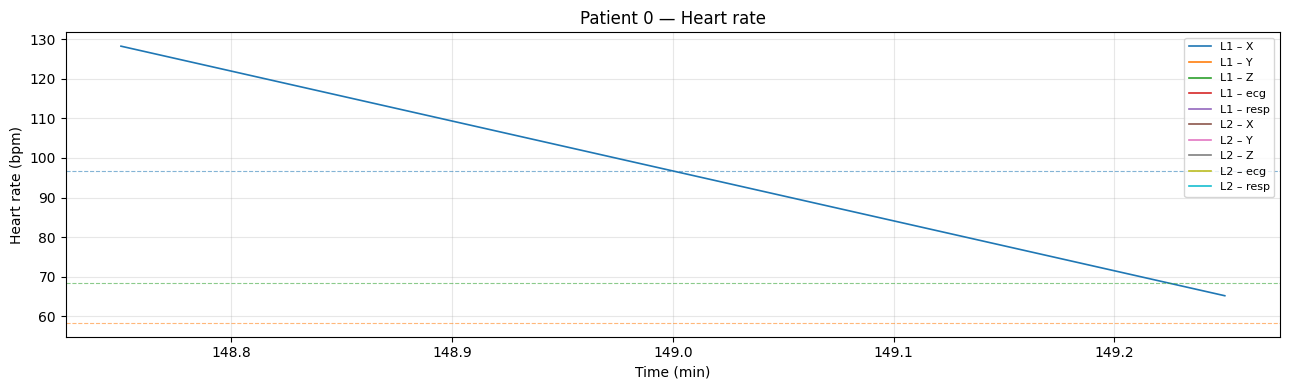

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))

for (sensor, channel), grp in ts_all.groupby(["sensor", "channel"], sort=False):
    t_min = grp["time_s"] / 60
    ax.plot(t_min, grp["hr_bpm"], label=f"{sensor} – {channel}", linewidth=1.2)
    mean_hr = grp["hr_bpm"].mean()
    if not np.isnan(mean_hr):
        ax.axhline(mean_hr, linestyle="--", linewidth=0.8, alpha=0.55,
                   color=ax.lines[-1].get_color())

ax.set_xlabel("Time (min)")
ax.set_ylabel("Heart rate (bpm)")
ax.set_title(f"{PATIENT_ID} — Heart rate")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fn.show_and_save_figure(fig, out_dir, f"{PATIENT_ID}_ecg_hr.png")

### HRV — time-domain (RMSSD & SDNN)

2026-03-24T08:22:31 | INFO     | functions | Saved figure: output/ecg_analysis/Patient 0/Patient 0_ecg_hrv_timedomain.png


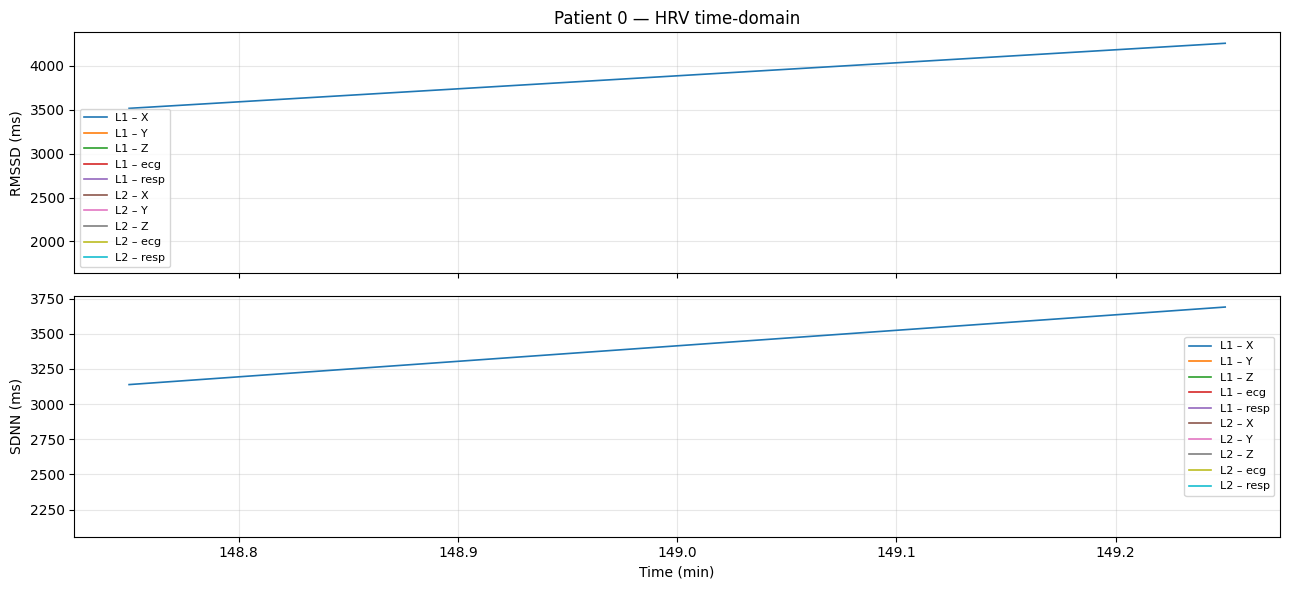

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

for (sensor, channel), grp in ts_all.groupby(["sensor", "channel"], sort=False):
    label = f"{sensor} – {channel}"
    t_min = grp["time_s"] / 60
    axes[0].plot(t_min, grp["rmssd_ms"], label=label, linewidth=1.2)
    axes[1].plot(t_min, grp["sdnn_ms"],  label=label, linewidth=1.2)

for ax, metric in zip(axes, ["RMSSD (ms)", "SDNN (ms)"]):
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f"{PATIENT_ID} — HRV time-domain")
axes[1].set_xlabel("Time (min)")
fig.tight_layout()
fn.show_and_save_figure(fig, out_dir, f"{PATIENT_ID}_ecg_hrv_timedomain.png")

### HRV — frequency-domain (LF, HF, LF/HF)

> Values are exploratory at the default 30-second window length. The clinical standard requires ≥ 5-minute windows.

2026-03-24T08:22:32 | INFO     | functions | Saved figure: output/ecg_analysis/Patient 0/Patient 0_ecg_hrv_freqdomain.png


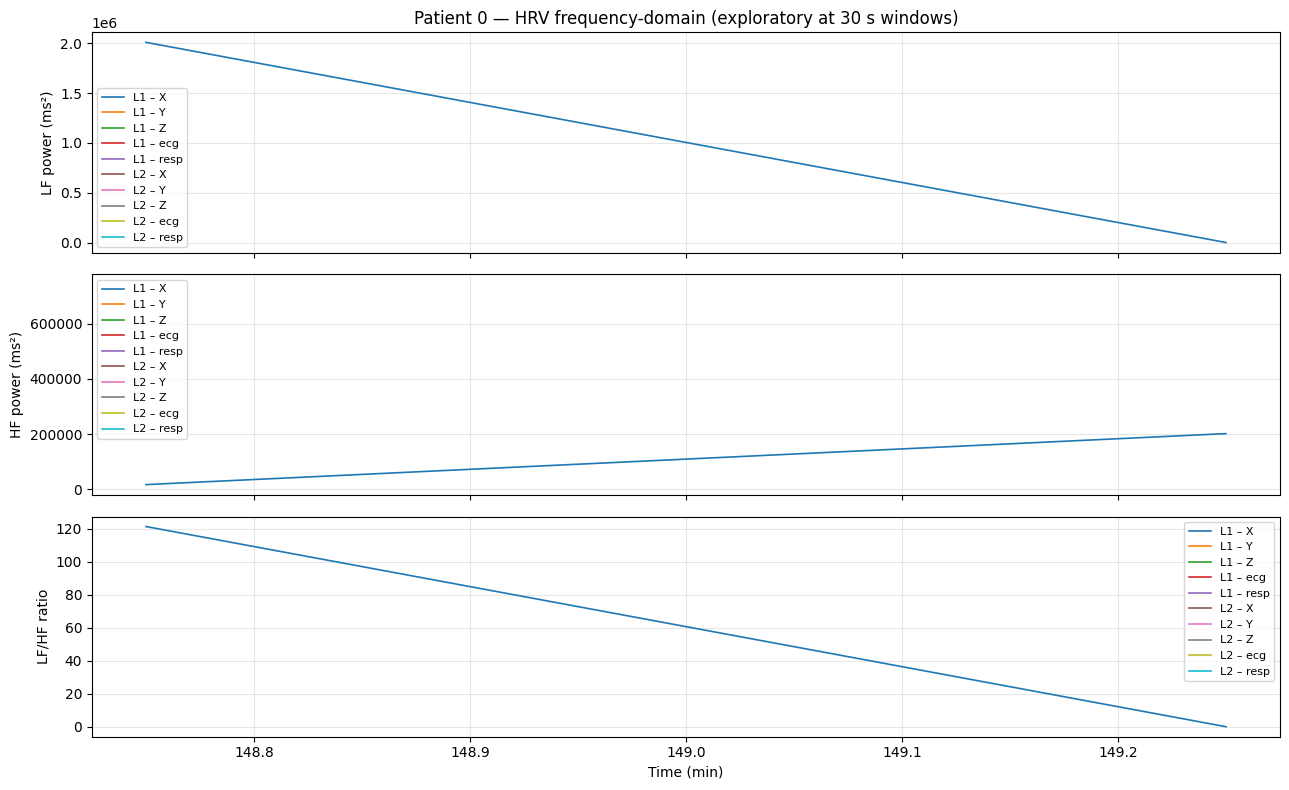

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
metrics_freq = [
    ("lf_ms2",      "LF power (ms²)"),
    ("hf_ms2",      "HF power (ms²)"),
    ("lf_hf_ratio", "LF/HF ratio"),
]

for (sensor, channel), grp in ts_all.groupby(["sensor", "channel"], sort=False):
    label = f"{sensor} – {channel}"
    t_min = grp["time_s"] / 60
    for ax, (col, _) in zip(axes, metrics_freq):
        ax.plot(t_min, grp[col], label=label, linewidth=1.2)

axes[0].set_title(f"{PATIENT_ID} — HRV frequency-domain (exploratory at {WINDOW_DURATION:.0f} s windows)")
for ax, (_, ylabel) in zip(axes, metrics_freq):
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (min)")
fig.tight_layout()
fn.show_and_save_figure(fig, out_dir, f"{PATIENT_ID}_ecg_hrv_freqdomain.png")

### Breathing rate over time (ECG-derived respiration)

Estimated from the amplitude modulation of R-peaks — a well-established ECG-derived respiration (EDR) proxy. Cross-validate against the VE column from telemetry data where available.

2026-03-24T08:22:33 | INFO     | functions | Saved figure: output/ecg_analysis/Patient 0/Patient 0_ecg_breathing.png


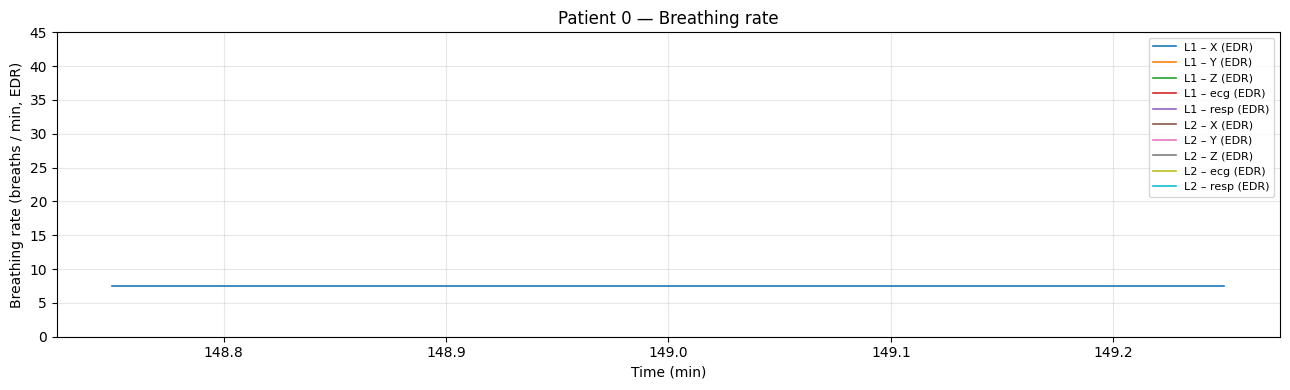

In [9]:
fig, ax = plt.subplots(figsize=(13, 4))

for (sensor, channel), grp in ts_all.groupby(["sensor", "channel"], sort=False):
    ax.plot(grp["time_s"] / 60, grp["breathing_rate_bpm"],
            label=f"{sensor} – {channel} (EDR)", linewidth=1.2)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Breathing rate (breaths / min, EDR)")
ax.set_title(f"{PATIENT_ID} — Breathing rate")
ax.set_ylim(0, 45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fn.show_and_save_figure(fig, out_dir, f"{PATIENT_ID}_ecg_breathing.png")

### ECG raw signal preview (first 10 seconds)

Visual quality check of the raw signal and detected R-peaks.

2026-03-24T08:34:30 | INFO     | functions | Saved figure: output/ecg_analysis/Patient 0/Patient 0_ecg_raw_preview.png


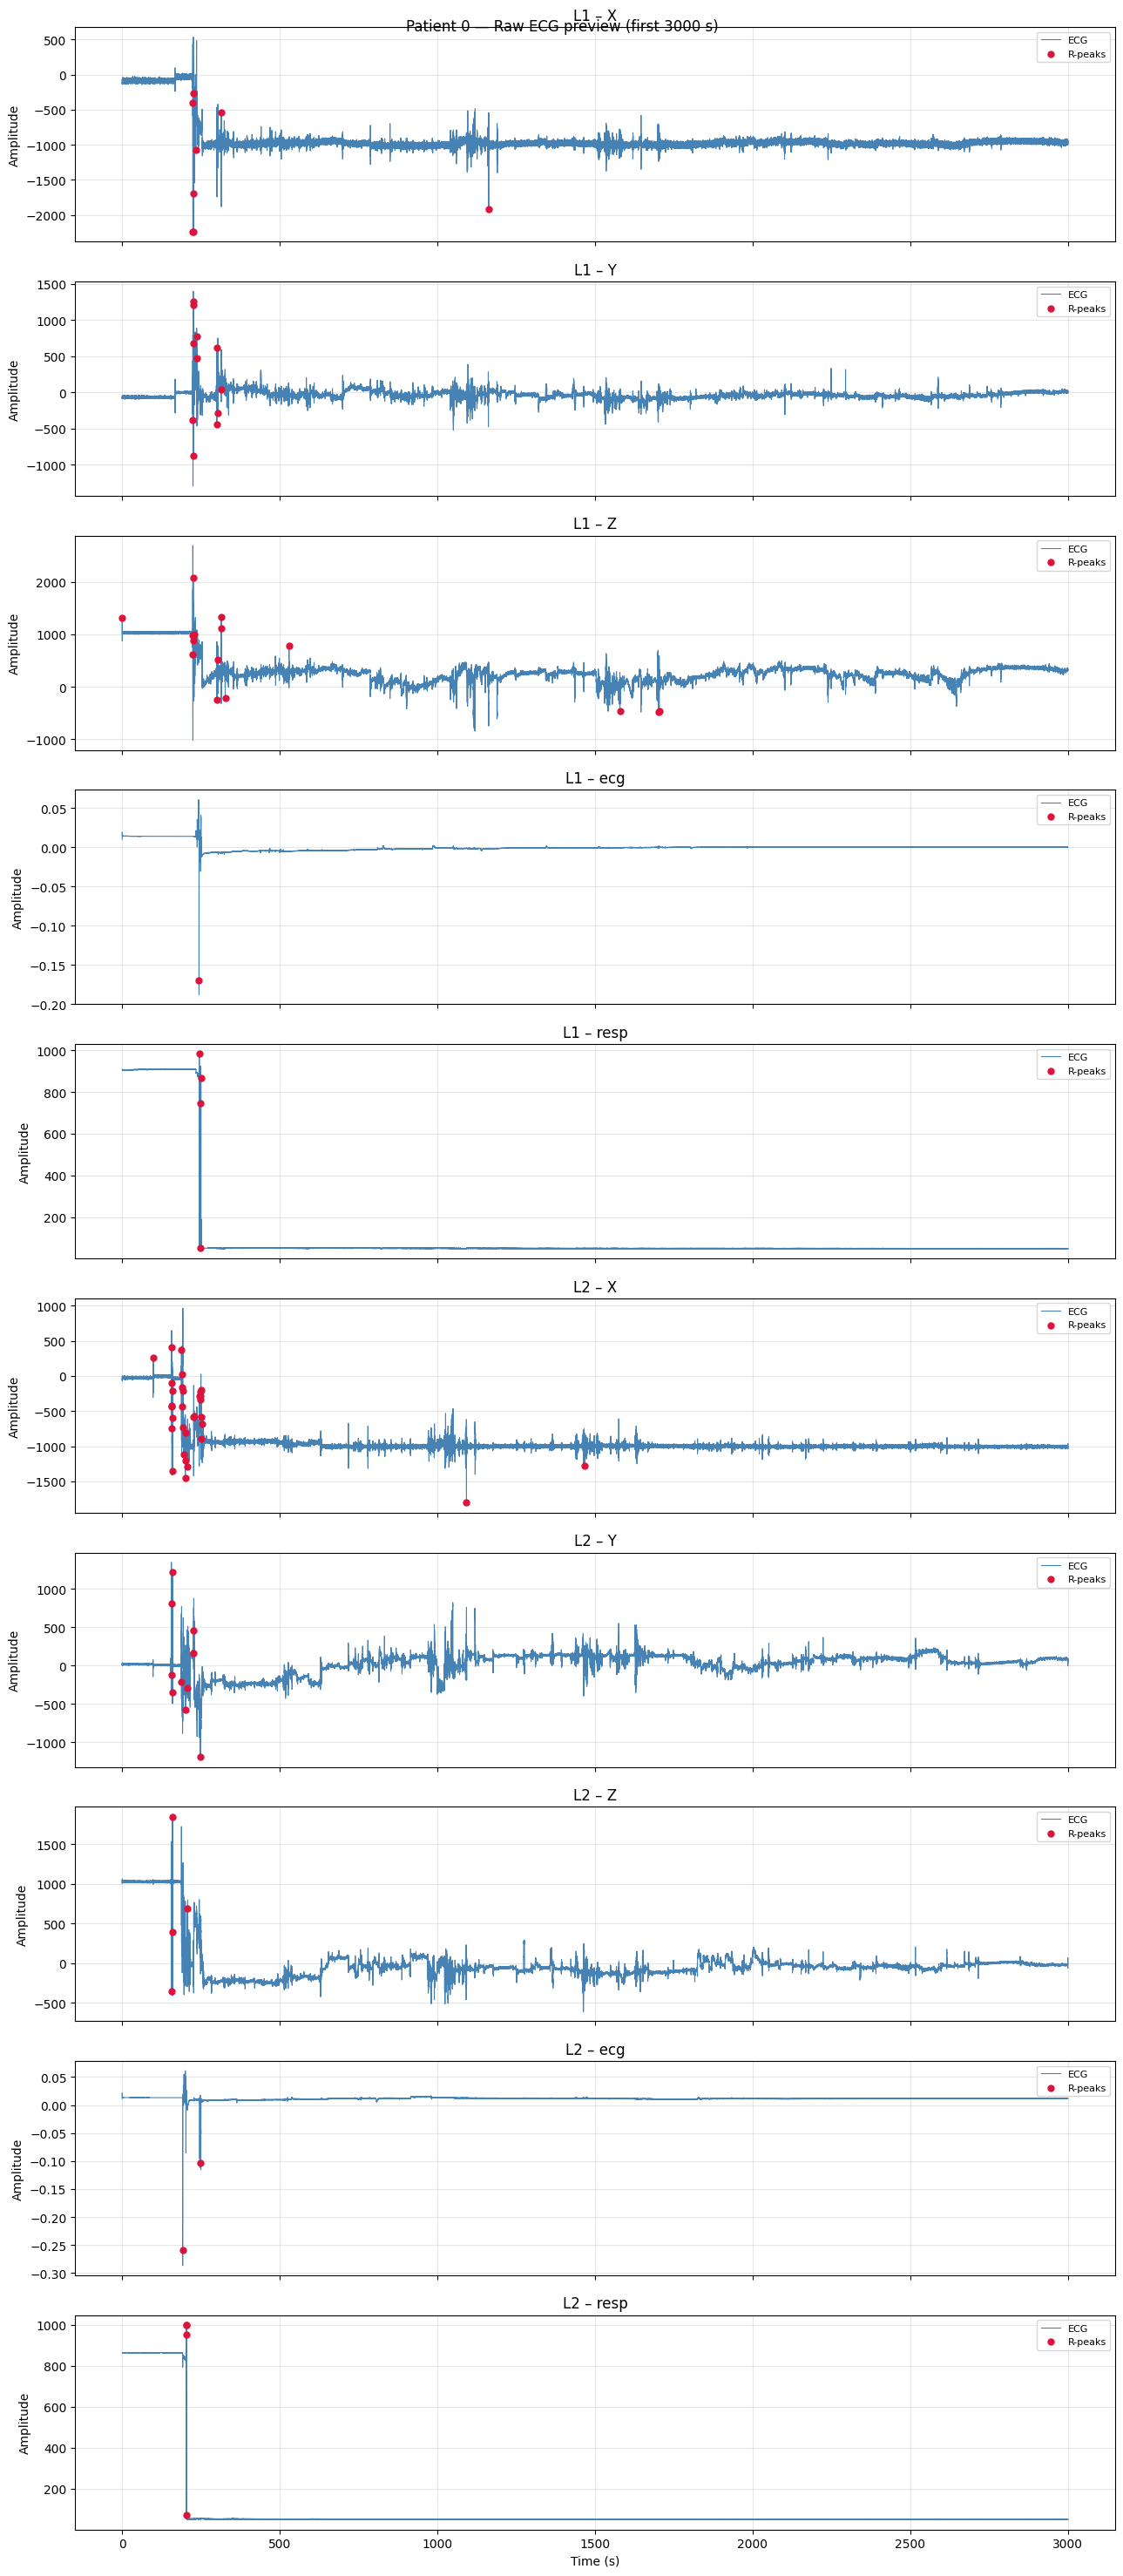

In [21]:
PREVIEW_SECONDS = 3000

n_panels = sum(s["data"].shape[0] for s in sensors.values())
fig, axes = plt.subplots(n_panels, 1, figsize=(13, 3 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

panel = 0
for sensor_label, s in sensors.items():
    sfreq  = s["sfreq"]
    n_show = int(PREVIEW_SECONDS * sfreq)
    t_show = np.arange(n_show) / sfreq

    for ch_idx, ch_name in enumerate(s["ch_names"]):
        sig = s["data"][ch_idx, :n_show].astype(float)

        # Detect R-peaks in the preview segment only.
        r_peaks = fn._detect_r_peaks(sig, sfreq)

        ax = axes[panel]
        ax.plot(t_show, sig, linewidth=0.8, color="steelblue", label="ECG")
        if len(r_peaks):
            ax.scatter(r_peaks / sfreq, sig[r_peaks], color="crimson", s=25,
                       zorder=3, label="R-peaks")
        ax.set_ylabel("Amplitude")
        ax.set_title(f"{sensor_label} – {ch_name}")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)
        panel += 1

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"{PATIENT_ID} — Raw ECG preview (first {PREVIEW_SECONDS} s)", fontsize=12)
fig.tight_layout()
fn.show_and_save_figure(fig, out_dir, f"{PATIENT_ID}_ecg_raw_preview.png")

### Summary statistics for this patient

In [11]:
summary_cols = ["hr_bpm", "rmssd_ms", "sdnn_ms", "lf_ms2", "hf_ms2",
                "lf_hf_ratio", "breathing_rate_bpm"]
ts_all[summary_cols].describe().round(2)

,hr_bpm,rmssd_ms,sdnn_ms,lf_ms2,hf_ms2,lf_hf_ratio,breathing_rate_bpm
count,4.00,4.00,4.00,4.00,4.00,4.00,4.0
mean,80.07,2888.94,2798.14,1311513.69,369758.42,31.70,7.5
std,32.37,1197.26,747.38,894263.97,323631.99,59.87,0.0
min,58.37,1764.68,2134.32,0.00,16551.58,0.00,7.5
25%,63.50,1952.26,2205.66,1185583.70,155332.05,1.60,7.5
50%,66.86,2765.94,2684.04,1617678.10,359823.47,2.66,7.5
75%,83.42,3702.62,3276.52,1743608.09,574249.85,32.77,7.5
max,128.21,4259.19,3690.17,2010698.58,742835.16,121.48,7.5


---
## Part B — Batch summary across all patients

In [12]:
summary_rows = []

for fold in all_folders:
    pid = fold.name
    l1, l2 = fn.find_bdf_files(fold)

    frames = []
    for sensor_label, bdf_path in [("L1", l1), ("L2", l2)]:
        if bdf_path is None:
            continue
        raw = fn.load_ecg(bdf_path)
        if raw is None:
            print(f"  {pid} {sensor_label}: load failed")
            continue
        d, sf, ch = raw.get_data(), int(raw.info["sfreq"]), raw.ch_names
        ts = fn.extract_ecg_timeseries_array(d, sf, ch, window_duration=WINDOW_DURATION)
        ts.insert(0, "sensor", sensor_label)
        frames.append(ts)

    if not frames:
        print(f"  {pid}: no usable BDF data — skipping")
        continue

    ts_pat = pd.concat(frames, ignore_index=True)
    summary_rows.append(
        dict(
            patient_id=pid,
            mean_hr_bpm        = ts_pat["hr_bpm"].mean(),
            mean_rmssd_ms      = ts_pat["rmssd_ms"].mean(),
            mean_sdnn_ms       = ts_pat["sdnn_ms"].mean(),
            mean_lf_ms2        = ts_pat["lf_ms2"].mean(),
            mean_hf_ms2        = ts_pat["hf_ms2"].mean(),
            mean_lf_hf         = ts_pat["lf_hf_ratio"].mean(),
            mean_breathing_bpm = ts_pat["breathing_rate_bpm"].mean(),
        )
    )
    print(f"  {pid}: done")

batch_df = pd.DataFrame(summary_rows)
print(f"\nBatch complete: {len(batch_df)} patients")
batch_df


2026-03-24T08:22:35 | INFO     | functions | Loaded BDF: WESENSETEST_04_L1_ECG_20260109T150411_AM.bdf  (8997.0 s)
2026-03-24T08:22:37 | INFO     | functions | Loaded BDF: WESENSETEST_04_L2_ECG_20260109T150520_AM.bdf  (9010.0 s)


  Patient 0: done
  Patient 2601: no usable BDF data — skipping
  Patient 2602: no usable BDF data — skipping
  Patient 2603: no usable BDF data — skipping
  Patient 2604: no usable BDF data — skipping
  Patient 2605: no usable BDF data — skipping
  Patient 2606: no usable BDF data — skipping

Batch complete: 1 patients


,patient_id,mean_hr_bpm,mean_rmssd_ms,mean_sdnn_ms,mean_lf_ms2,mean_hf_ms2,mean_lf_hf,mean_breathing_bpm
0,Patient 0,80.070357,2888.939527,2798.142989,1.311514e+06,369758.420088,31.700655,7.5


2026-03-24T08:22:38 | INFO     | functions | Saved figure: output/ecg_batch_summary.png


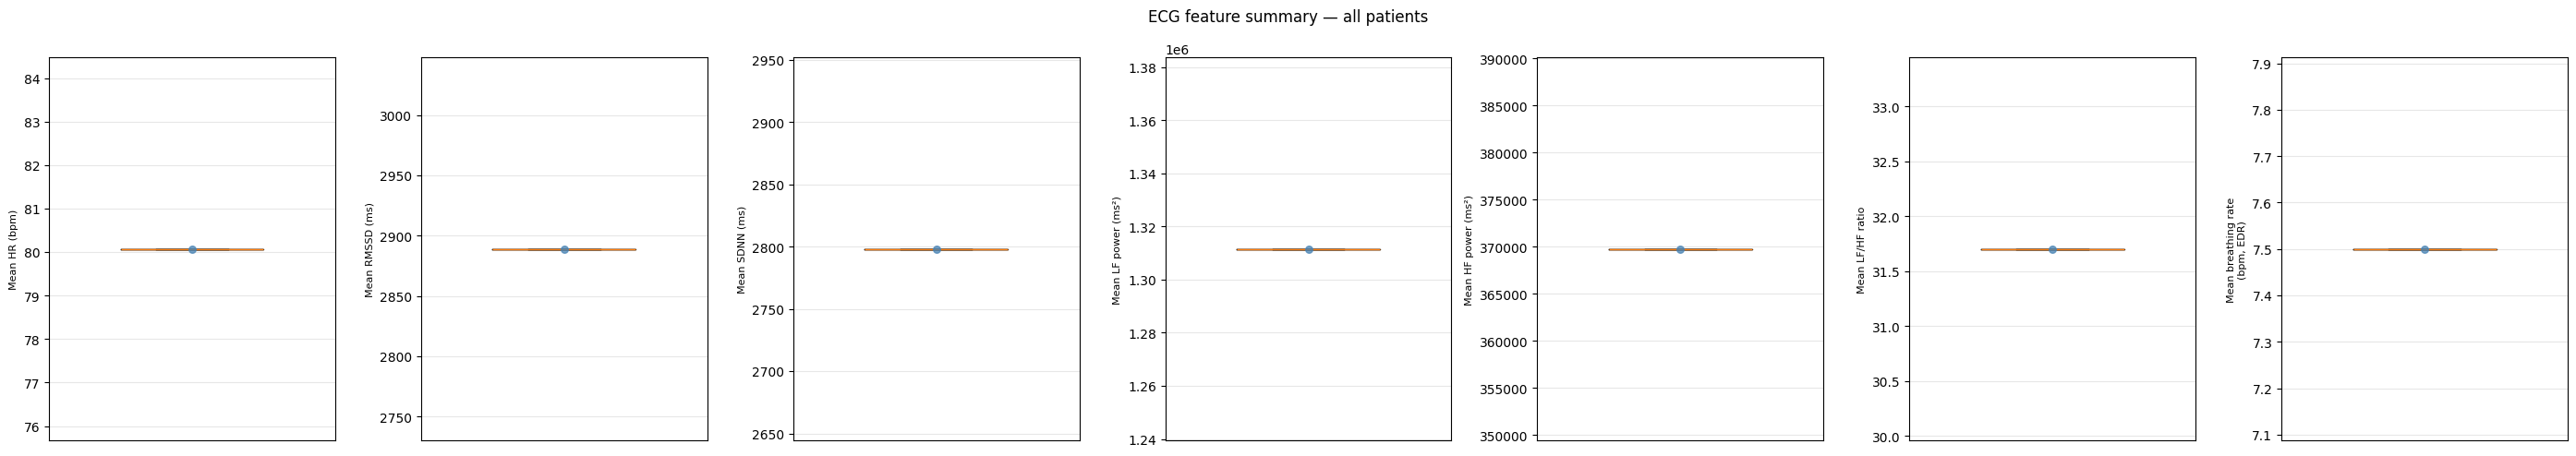

In [13]:
metrics_batch = [
    ("mean_hr_bpm",         "Mean HR (bpm)"),
    ("mean_rmssd_ms",       "Mean RMSSD (ms)"),
    ("mean_sdnn_ms",        "Mean SDNN (ms)"),
    ("mean_lf_ms2",         "Mean LF power (ms²)"),
    ("mean_hf_ms2",         "Mean HF power (ms²)"),
    ("mean_lf_hf",          "Mean LF/HF ratio"),
    ("mean_breathing_bpm",  "Mean breathing rate\n(bpm, EDR)"),
]

n = len(metrics_batch)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))

for ax, (col, ylabel) in zip(axes, metrics_batch):
    vals = batch_df[col].dropna().values
    if len(vals):
        ax.boxplot(vals, widths=0.5)
        ax.scatter(np.ones(len(vals)), vals, color="steelblue", s=30,
                   zorder=3, alpha=0.75)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks([])
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("ECG feature summary — all patients", fontsize=12)
fig.tight_layout()

batch_out = Path(OUTPUT_ROOT)
batch_out.mkdir(parents=True, exist_ok=True)
fn.show_and_save_figure(fig, batch_out, "ecg_batch_summary.png")